# Fixed-Bottom Substructure Installation Models in ORBIT

This guide walks through the use of three separate substructure and turbine installation methods
listed below. All configuration files for this guide can be found in the
[`examples/configs/`](https://github.com/NLRWindSystems/ORBIT/tree/main/examples/configs)
folder.

1. Separate monopile and turbine installation using a heavy lift vessel (HLV) for the monopiles
   and wind turbine installation vessel (WTIV) for the turbines.
2. Onshore assembly of the gravity-based foundation (GBF) and turbine, tow out and joint
   installation at site.
3. Tow-out of the GBF and turbine installation using the WTIV.

First, we'll import the required libraries and functionality, and initialize any common variables.

In [1]:
import copy
from pprint import pprint
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from ORBIT import ProjectManager, load_config

# Apply thousands separators and no decimals to floats
pd.options.display.float_format = '{:,.0f}'.format

# Set the example path for use in the docs and standalone examples usage
here = Path(".").resolve()
example_path = here.parents[1] / "examples" if here.stem == "topical_guides" else here

weather = pd.read_csv(
    example_path / "data/example_weather.csv", parse_dates=["datetime"]
).set_index("datetime")

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.


## Load The Configurations

Each of cases 1 and 2 have their own configuration file, however the third case is highly similar
to Case 2, so we will make a distinct copy of it, and add the turbine installation phase to
indicate the separate substructure and turbine installations.

In [2]:
case1_config = load_config(example_path / "configs/example_separate_monopile_turbine_vessel.yaml")
case2_config = load_config(example_path / "configs/example_gravity_based_project.yaml")

case3_config = copy.deepcopy(case2_config)
case3_config["wtiv"] = "example_wtiv"
case3_config["install_phases"]["TurbineInstallation"] = 0

The primary differences between these projects deal with the installation strategies, and
required design stages to support them. Below, we note these differences, but highlighting
the installation phases that will be modeled.

Note that the `TurbineInstallation` model is only required for projects involving a WTIV (Case 1
and 2). The `GravityBasedInstallation` model offers flexibility so that if a WTIV is not specified
in the configuration file, then it models the tow-out of a fully assembled substructure and turbine;
and, if a WTIV is present, it models the tow-out of the substructure alone with discrete GBF
and turbine installation phases.

In [3]:
print(f"Monopile and Turbine Installation (Heavy Lift Vessel for Monopile Installation, WTIV for Turbine Installation)")
print(f"Install phases: {list(case1_config['install_phases'].keys())}\n")
print(f"Gravity-Based Foundation Intallation (Substructure-Turbine Assembly Tow-out, no WTIV)")
print(f"Install phases: {list(case2_config['install_phases'].keys())}\n")
print(f"Gravity-Based Foundation and Turbine Intallation (Substructure Tow-out, WTIV for Turbine Installation)")
print(f"Install phases: {list(case3_config['install_phases'].keys())}\n")

Monopile and Turbine Installation (Heavy Lift Vessel for Monopile Installation, WTIV for Turbine Installation)
Install phases: ['ArrayCableInstallation', 'ExportCableInstallation', 'TurbineInstallation', 'OffshoreSubstationInstallation', 'ScourProtectionInstallation', 'MonopileInstallation']

Gravity-Based Foundation Intallation (Substructure-Turbine Assembly Tow-out, no WTIV)
Install phases: ['ArrayCableInstallation', 'ExportCableInstallation', 'GravityBasedInstallation', 'OffshoreSubstationInstallation']

Gravity-Based Foundation and Turbine Intallation (Substructure Tow-out, WTIV for Turbine Installation)
Install phases: ['ArrayCableInstallation', 'ExportCableInstallation', 'GravityBasedInstallation', 'OffshoreSubstationInstallation', 'TurbineInstallation']


## Run The Three Cases

This project is always being modeled with the example weather project supplied that is representative of US East Coast wind farm locations.

In [4]:
case1_project = ProjectManager(case1_config, weather=weather)
case1_project.run()

case2_project = ProjectManager(case2_config, weather=weather)
case2_project.run()

case3_project = ProjectManager(case3_config, weather=weather)
case3_project.run()

ORBIT library intialized at '/Users/rhammond/GitHub_Public/ORBIT/library'


support_vessel will be deprecated and replaced with towing_vessels and ahts_vessel in the towing groups.


## Results Comparison

### CapEx Breakdown

In [5]:
# The breakdown of project costs by module is available  at 'capex_breakdown'

df = pd.DataFrame({
    'Monopiles + WTIV': pd.Series(case1_project.capex_breakdown),
    'GBF-Turbine Assembly Tow-out': case2_project.capex_breakdown,
    'GBF Tow-out + WTIV': pd.Series(case3_project.capex_breakdown)
}).fillna(0)
df.loc['Total'] = df.sum()
df.index.name = "CapEx Component"
df

,Monopiles + WTIV,GBF-Turbine Assembly Tow-out,GBF Tow-out + WTIV
CapEx Component,,,
Array System,"61,594,993","61,594,993","61,594,993"
Array System Installation,"58,448,335","58,448,335","58,448,335"
Export System,"358,235,289","358,235,289","358,235,289"
Export System Installation,"24,499,859","24,499,859","24,499,859"
Offshore Substation,"307,307,330","307,307,330","307,307,330"
Offshore Substation Installation,"5,095,600","5,095,600","5,095,600"
Onshore Substation,0,0,0
Project,"355,000,000","355,000,000","355,000,000"
Scour Protection,"6,618,000",0,0


In [6]:
def plot_capex_comparison(df, num_turbines, project_capacity_mw, top_limit=4000):
    # Reformat the data for easier plotting
    ix_order = ["Monopiles + WTIV", "GBF-Turbine Assembly Tow-out", "GBF Tow-out + WTIV"]
    df = df.copy()
    df.columns = df.columns.str.strip()
    df /= 1e6
    df = df.drop("Total").T.loc[ix_order]

    capacity_kw = project_capacity_mw * 1000

    # Colors for components
    colors = plt.get_cmap("tab20").colors
    component_order = df.columns.tolist()
    color_map = {component: colors[i % len(colors)] for i, component in enumerate(component_order)}

    fig = plt.figure(figsize=(14, 14))
    ax = fig.add_subplot(111)

    bar_width = 0.7  # Slightly thinner bars
    bottoms = np.zeros(len(df))
    for component in component_order:
        vals = df[component].values
        bars = ax.bar(
            df.index,
            vals,
            bottom=bottoms,
            width=bar_width,
            color=color_map[component],
            edgecolor="black",
            linewidth=0.8,
            label=component
        )
        bottoms += vals

        # Add text inside each stacked segment if $/kW >= 40
        for i, val_musd in enumerate(vals):
            if val_musd == 0:
                continue
            val_usd = val_musd * 1e6
            val_per_kw = val_usd / capacity_kw
            val_per_wtg_musd = val_musd / num_turbines

            if val_per_kw >= 40:
                y_pos = bars[i].get_y() + bars[i].get_height() / 2
                text = (
                    f"${val_musd:,.1f}M | "
                    f"${val_per_kw:,.0f}/kW | "
                    f"${val_per_wtg_musd:,.2f}M/WTG"
                )
                ax.text(
                    i,
                    y_pos,
                    text,
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="black"
                )

    # Add total values text on top of bars
    total_musd = df.sum(axis=1)
    for i, total in enumerate(total_musd):
        total_usd = total * 1e6
        total_per_kw = total_usd / capacity_kw
        total_per_wtg_musd = total / num_turbines
        text = (
            f"Total:\n"
            f"${total:,.1f}M | "
            f"${total_per_kw:,.0f}/kW | "
            f"${total_per_wtg_musd:,.2f}M/WTG"
        )
        ax.text(
            i,
            total * 1.005,
            text,
            ha="center",
            va="bottom",
            fontsize=9,
            color="black",
            fontweight="bold"
        )

    # Format y-axis ticks with commas
    ax.yaxis.set_major_formatter(ticker.StrMethodFormatter("{x:,.0f}"))

    ax.set_ylabel("CapEx ($ Millions)", fontweight="bold")
    ax.set_xlabel("Installation Strategy", fontweight="bold")
    ax.set_title("CapEx Breakdown by Component")
    ax.set_ylim(0, top_limit)
    ax.grid(axis="y", linestyle="--", alpha=0.7)

    ax.legend(title="CapEx Component", ncols=5, loc="upper center")
    fig.tight_layout()

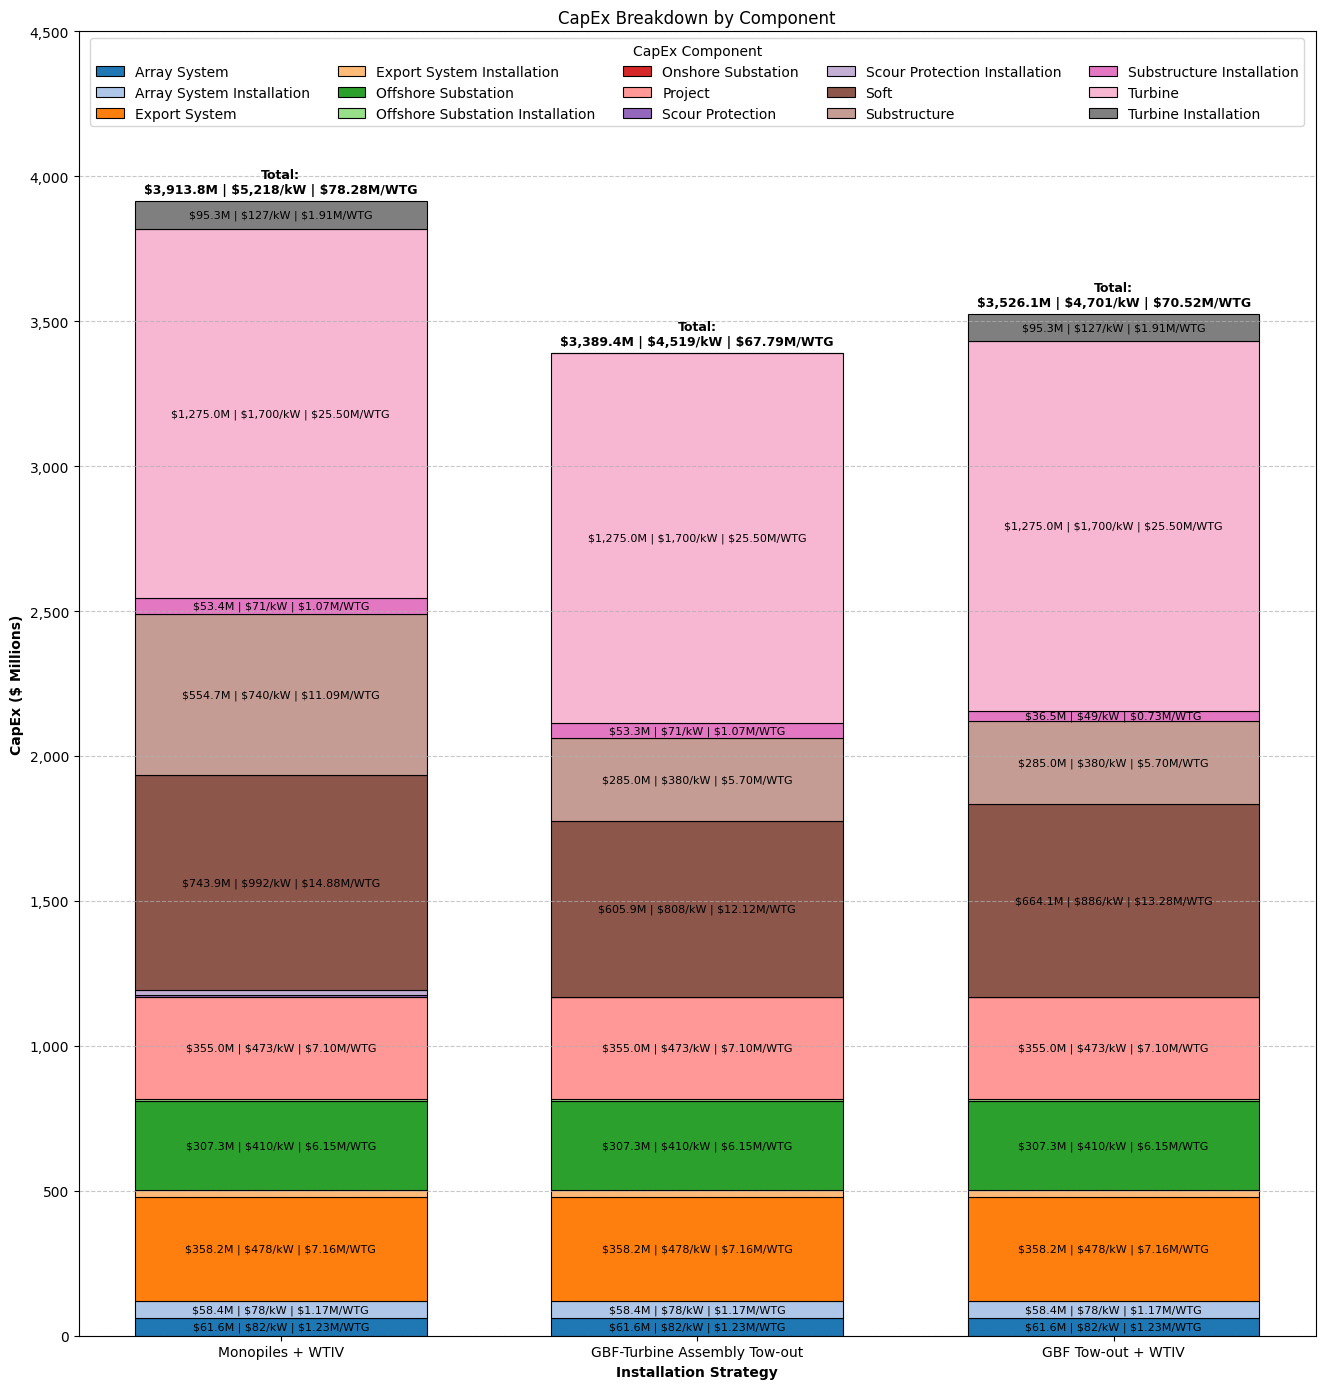

In [7]:
plot_capex_comparison(df, 50, 750, top_limit=4500)

### Substructure and Turbine Installation CapEx Breakdown

In [8]:
sub_turb_install_df = df.loc[["Substructure Installation", "Turbine Installation"]]
sub_turb_install_df.loc["Total"] = sub_turb_install_df.sum(axis=0)
sub_turb_install_df

,Monopiles + WTIV,GBF-Turbine Assembly Tow-out,GBF Tow-out + WTIV
CapEx Component,,,
Substructure Installation,"53,356,403","53,289,847","36,496,243"
Turbine Installation,"95,293,403",0,"95,293,403"
Total,"148,649,807","53,289,847","131,789,647"


### Comparing Installation Timing

Now we can compare the actual installation phase timing to demonstrate the effects of using
differing numbers of vessels and installation strategies. Notice that for both Case 1 and 3
the installations all start at the same date, which is likely unrealistic in practice as each
stage cannot happen at a single turbine at the same time, nor can the installation of scouring
protection be installed prior to the monopiles being installed.

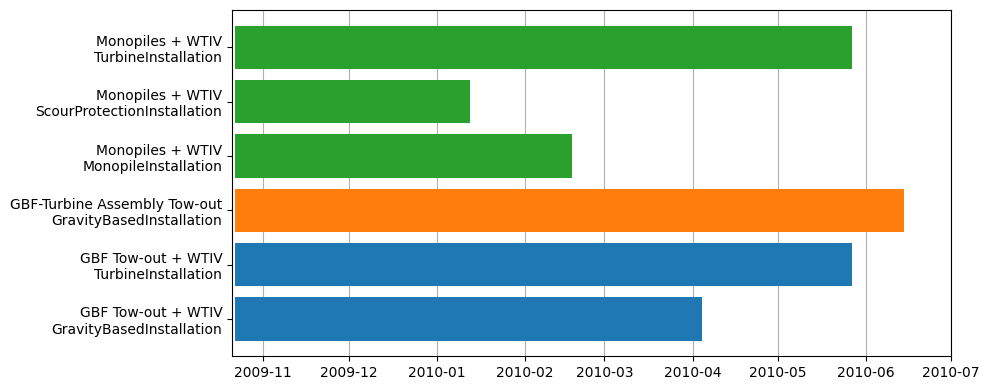

In [9]:
fig = plt.figure(figsize=(10, 4))
ax = fig.add_subplot(111)

cases = ["Monopiles + WTIV", "GBF-Turbine Assembly Tow-out", "GBF Tow-out + WTIV"]
case1_df = pd.DataFrame.from_dict(case1_project.phase_dates).T
case1_df = case1_df.loc[["MonopileInstallation", "ScourProtectionInstallation", "TurbineInstallation"]]
case1_df.start = pd.to_datetime(case1_df.start)
case1_df.end = pd.to_datetime(case1_df.end)
case1_df = case1_df.rename(index={ix: f"{cases[0]}\n{ix}" for ix in case1_df.index})

case2_df = pd.DataFrame.from_dict(case2_project.phase_dates).T
case2_df = case2_df.loc[["GravityBasedInstallation"]]
case2_df.start = pd.to_datetime(case2_df.start)
case2_df.end = pd.to_datetime(case2_df.end)
case2_df = case2_df.rename(index={ix: f"{cases[1]}\n{ix}" for ix in case2_df.index})

case3_df = pd.DataFrame.from_dict(case3_project.phase_dates).T
case3_df = case3_df.loc[["GravityBasedInstallation", "TurbineInstallation"]]
case3_df.start = pd.to_datetime(case3_df.start)
case3_df.end = pd.to_datetime(case3_df.end)
case3_df = case3_df.rename(index={ix: f"{cases[2]}\n{ix}" for ix in case3_df.index})

ax.barh(y=case3_df.index, width=case3_df.end - case3_df.start, left=case3_df.start);
ax.barh(y=case2_df.index, width=case2_df.end - case2_df.start, left=case2_df.start);
ax.barh(y=case1_df.index, width=case1_df.end - case1_df.start, left=case1_df.start);

ax.grid(axis="x")
ax.set_axisbelow(True)
ax.set_xlim(pd.to_datetime("2009-10-21"), pd.to_datetime("2010-07"))
fig.tight_layout()